---
tags: [tutorial]
---

# 再利用パターン：QKernelの合成とコンポジットゲート

回路が大きくなると、ゲート列のコピー＆ペーストを避けたくなります。Qamomileは2つの再利用メカニズムを提供しています：

1. **ヘルパーQKernel** — ある`@qkernel`を別の`@qkernel`から呼び出す、通常の関数合成と同じ方法です。
2. `@composite_gate` — 量子カーネルをカスタム可能な名前付きゲートに昇格させ、図中で単一のボックスとして表示します。

さらにトップダウン設計のための第3のパターンもあります：

3. **不透明オラクル** — 実装本体を持たない呼び出しで、トップダウン設計とリソース推定に使います。完全なオラクル実装がなくても、呼び出し構造を推定できます。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install "qamomile[qiskit,visualization]"

In [2]:
import qamomile.circuit as qmc
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## パターン1:ヘルパーQKernel

どの`@qkernel`関数も別の`@qkernel`から呼び出せます。トランスパイル時にインライン展開されるため、トランスパイル結果はフラットな回路になります。

In [3]:
@qmc.qkernel
def entangle_once(q0: qmc.Qubit, q1: qmc.Qubit) -> tuple[qmc.Qubit, qmc.Qubit]:
    q0, q1 = qmc.cx(q0, q1)
    return q0, q1


@qmc.qkernel
def ghz_with_helper(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q[0] = qmc.h(q[0])

    for i in qmc.range(n - 1):
        q[i], q[i + 1] = entangle_once(q[i], q[i + 1])

    return qmc.measure(q)

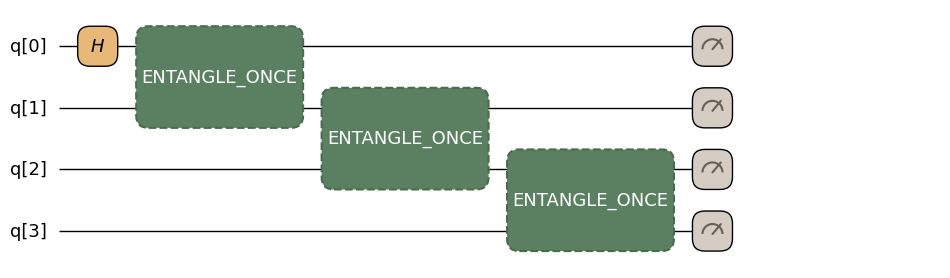

In [4]:
ghz_with_helper.draw(n=4, fold_loops=False)

In [5]:
result = (
    transpiler.transpile(ghz_with_helper, bindings={"n": 4})
    .sample(
        transpiler.executor(),
        shots=128,
    )
    .result()
)
print("GHZ result:", result.results)
assert result.shots == 128
assert sum(count for _, count in result.results) == 128
# 4 量子ビット GHZ 状態 → (0, 0, 0, 0) と (1, 1, 1, 1) のみ出現。
assert all(outcome in {(0, 0, 0, 0), (1, 1, 1, 1)} for outcome, _ in result.results)

GHZ result: [((1, 1, 1, 1), 70), ((0, 0, 0, 0), 58)]


ヘルパー`entangle_once`により、呼び出し側のコードが読みやすくなります。トランスパイル後の回路ではインライン展開されるため、サブブロックではなく個々のCXゲートが見えます。

In [6]:
qc = transpiler.to_circuit(ghz_with_helper, bindings={"n": 4})
print(qc.draw())

     ┌───┐          ┌─┐              
q_0: ┤ H ├──■───────┤M├──────────────
     └───┘┌─┴─┐     └╥┘     ┌─┐      
q_1: ─────┤ X ├──■───╫──────┤M├──────
          └───┘┌─┴─┐ ║      └╥┘┌─┐   
q_2: ──────────┤ X ├─╫───■───╫─┤M├───
               └───┘ ║ ┌─┴─┐ ║ └╥┘┌─┐
q_3: ────────────────╫─┤ X ├─╫──╫─┤M├
                     ║ └───┘ ║  ║ └╥┘
c: 4/════════════════╩═══════╩══╩══╩═
                     0       1  2  3 


### ヘルパーへのスカラーリテラルの受け渡し

ヘルパーqkernelがスカラー型(`UInt`,`Float`,`Bit`)のパラメータを宣言している場合、呼び出し側ではPythonの生のリテラルをそのまま渡せます。Qamomileが`int`を`UInt`、`float`を`Float`、`bool`を`Bit`に自動昇格します。`helper(q, 0, 0.5)`は`helper(q, qmc.uint(0), qmc.float_(0.5))`と等価です。明示的な`qmc.uint`/`qmc.float_`/`qmc.bit`コンストラクタは、値に名前を付けたい場合や複数の呼び出し箇所で共有したい場合にのみ使えば十分です。

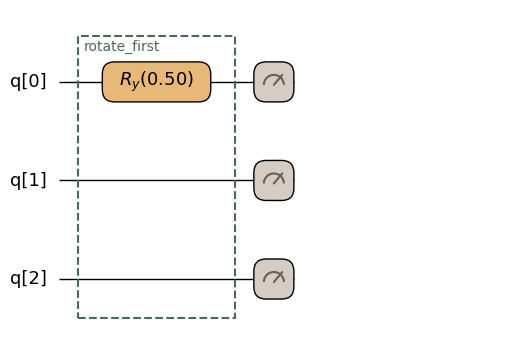

In [7]:
@qmc.qkernel
def rotate_first(
    q: qmc.Vector[qmc.Qubit],
    idx: qmc.UInt,
    angle: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    q[idx] = qmc.ry(q[idx], angle)
    return q


@qmc.qkernel
def helper_with_literals(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    # int / float リテラルは runtime で ``qmc.UInt`` / ``qmc.Float`` に
    # auto-promote されるが、kernel の静的シグネチャは Qamomile ハンドル型を
    # そのまま要求する。下の ignore はその意図的なギャップを明示するもの。
    q = rotate_first(q, 0, 0.5)  # type: ignore[arg-type]
    return qmc.measure(q)


helper_with_literals.draw(n=3, fold_loops=False, inline=True)

## 大きなワークスペースを`qmc.struct`で整理する

小さなヘルパーでは、使用する量子ビットやレジスタを個別の引数として渡しても十分に読みやすく保てます。一方、多くの量子ビットや補助レジスタを同時に扱う実装では、関数の引数と戻り値が長くなりがちです。

`@qmc.struct`を使うと、関連するQamomileハンドルを名前付きフィールドにまとめられます。次の例では、Bell状態の準備に使う2つの量子ビットを`BellWorkspace`として扱います。

In [8]:
@qmc.struct
class BellWorkspace:
    control: qmc.Qubit
    target: qmc.Qubit


def prepare_bell(workspace: BellWorkspace) -> BellWorkspace:
    control = qmc.h(workspace.control)
    control, target = qmc.cx(control, workspace.target)
    return BellWorkspace(control=control, target=target)


@qmc.qkernel
def bell_with_workspace() -> tuple[qmc.Bit, qmc.Bit]:
    workspace = BellWorkspace(
        control=qmc.qubit("control"),
        target=qmc.qubit("target"),
    )
    workspace = prepare_bell(workspace)
    return qmc.measure(workspace.control), qmc.measure(workspace.target)

`prepare_bell`はworkspaceを受け取り、ゲートが返した新しいハンドルを持つ`BellWorkspace`を返します。`qmc.struct`はimmutableなrecordとして扱い、呼び出し側では`workspace = prepare_bell(workspace)`と受け直します。これにより、現在のハンドルを保持するrecordがコード上で明確になります。

フィールドに入っている`Qubit`や`Vector[Qubit]`には、通常と同じアフィン規則が適用されます。structを別の変数へ代入した場合、二つのrecordは同じ量子ハンドルを参照します。各量子操作が返したハンドルを新しいrecordへ渡し、以降の処理ではそのrecordを使います。`Vector[Qubit]`の要素に対するborrowと返却はVector自身が管理します。

`BellWorkspace`は回路のトレース中に、関連するハンドルを名前付きフィールドへ整理します。生成されるIRにはフィールド内の量子操作が記録されます。リソース推定を使うと、2量子ビットのBell回路として構築されたことを確認できます。

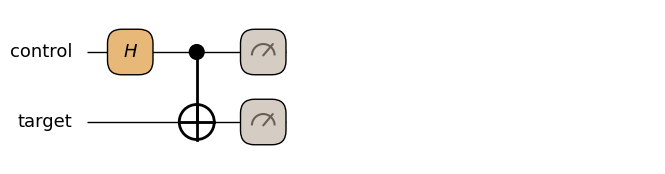

In [9]:
workspace_estimate = bell_with_workspace.estimate_resources()

assert bell_with_workspace.input_types == {}
assert workspace_estimate.qubits == 2
assert workspace_estimate.gates.single_qubit == 1
assert workspace_estimate.gates.two_qubit == 1

bell_with_workspace.draw()

In [10]:
workspace_result = (
    transpiler.transpile(bell_with_workspace)
    .sample(
        transpiler.executor(),
        shots=128,
    )
    .result()
)
print("Bell result:", workspace_result.results)
assert workspace_result.shots == 128
assert sum(count for _, count in workspace_result.results) == 128
assert all(outcome in {(0, 0), (1, 1)} for outcome, _ in workspace_result.results)

Bell result: [((1, 1), 66), ((0, 0), 62)]


:::{note}
qkernelのシグネチャには`Qubit`、`Vector[Qubit]`、`UInt`などのQamomile型を使います。`qmc.struct`は、トレース時にそれらのハンドルを整理し、通常のPythonヘルパーへまとめて渡すrecordとして使います。
:::

このようにワークスペースを一つの値として受け渡すと、多数のハンドルを長いタプルの代わりに名前付きフィールドで扱えます。

## パターン2：`@composite_gate`

再利用可能なブロックを回路図で**名前付きボックス**として表示したい場合`@composite_gate`でを使うこともできます。また、より高度な内容としてコンポジットゲートにすることで複数の実装方式を与えるといったカスタム設定を与えることも可能です。

`@qkernel`の上に`@composite_gate(name="...")`を重ねて書きます：

In [11]:
@qmc.composite_gate(name="entangle")
@qmc.qkernel
def entangle_link(q0: qmc.Qubit, q1: qmc.Qubit) -> tuple[qmc.Qubit, qmc.Qubit]:
    q0, q1 = qmc.cx(q0, q1)
    return q0, q1


@qmc.qkernel
def ghz_with_composite(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q[0] = qmc.h(q[0])

    for i in qmc.range(n - 1):
        q[i], q[i + 1] = entangle_link(q[i], q[i + 1])

    return qmc.measure(q)

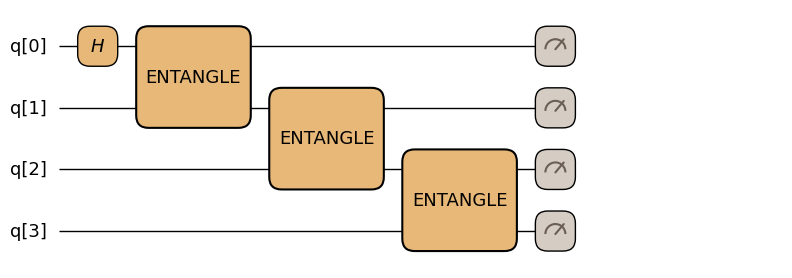

In [12]:
ghz_with_composite.draw(n=4, fold_loops=False)

### どちらを使うべきか?

| パターン | `draw()`での表示 | 使用場面 |
|---------|-------------------|--------------------------|
| ヘルパー`@qkernel` | インライン展開(フラット) | コードの整理 |
| `@composite_gate` | 名前付きボックス | ドメインレベルの抽象化/高度なカスタム |

## パターン3:トップダウン設計のための不透明オラクル

オラクル内部が未知のまま回路を組みたい場合は、名前・量子ビット数だけを持つ`qmc.Oracle`を使えます。

オラクルあるいはサブルーチンが開発中でも、アルゴリズム全体のコストを推定できます。

推定時に`UnknownResourcePolicy.OPAQUE_CALL`を指定すると、未実装の呼び出しをopaque call/queryとして記録します。

In [13]:
oracle_box = qmc.Oracle(
    name="oracle",
    num_qubits=3,
)


@qmc.qkernel
def algorithm_skeleton() -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(3, name="q")
    q = qmc.h(q)

    q[0], q[1], q[2] = oracle_box(q[0], q[1], q[2])
    return q

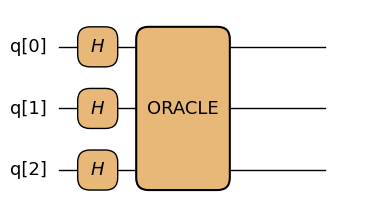

In [14]:
algorithm_skeleton.draw(fold_loops=False)

### 不透明オラクルを含むqkernelのリソース推定

`estimate_resources()`は、オラクル内部が未実装でもqkernel全体を解析できます。既知の回路部分は通常どおり集計され、未知部分は`est.calls.oracle_calls` / `est.calls.oracle_queries`として追跡されます。

In [15]:
est = algorithm_skeleton.estimate_resources(
    unknown_policy=qmc.UnknownResourcePolicy.OPAQUE_CALL,
).simplify()
print("qubits:", est.qubits)
assert est.qubits == 3
print("total gates:", est.gates.total)
# Hゲート3個は`gates.total`に、不透明な`oracle_box`は`calls.oracle_calls`に記録されます。
assert est.gates.total == 3

qubits: 3
total gates: 3


次に、通常ゲートと複数の不透明オラクルを混在させたqkernelで確認します。

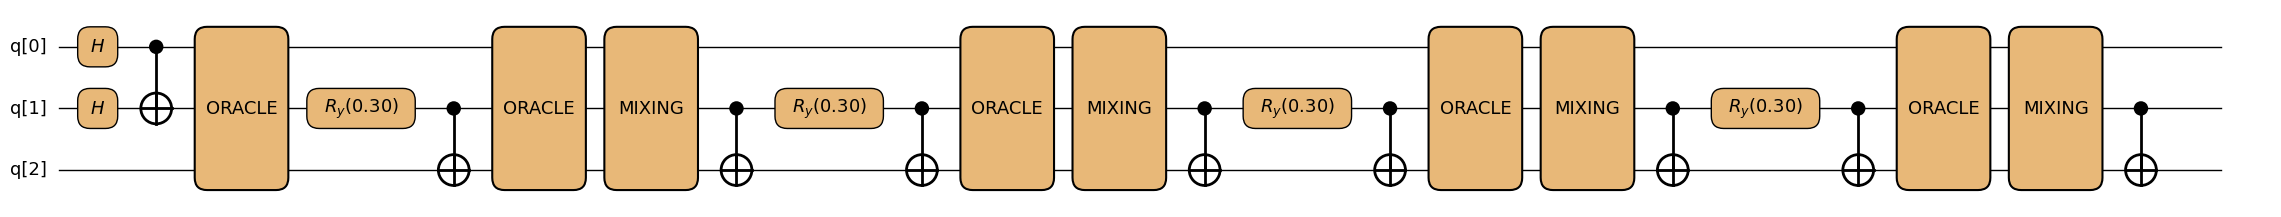

In [16]:
phase_oracle = qmc.Oracle(
    name="oracle",
    num_qubits=3,
)


mixing_oracle = qmc.Oracle(
    name="mixing",
    num_qubits=3,
)


@qmc.qkernel
def iterative_oracle_skeleton(rounds: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(3, name="q")

    # 既知の回路部分（非オラクル）
    q[0] = qmc.h(q[0])
    q[1] = qmc.h(q[1])
    q[0], q[1] = qmc.cx(q[0], q[1])

    # ループ外で 1 回オラクル呼び出し
    q[0], q[1], q[2] = phase_oracle(q[0], q[1], q[2])

    # 各ラウンドで既知ゲートと未知オラクルを混在
    for i in qmc.range(rounds):
        q[1] = qmc.ry(q[1], 0.3)
        q[1], q[2] = qmc.cx(q[1], q[2])
        q[0], q[1], q[2] = phase_oracle(q[0], q[1], q[2])
        q[0], q[1], q[2] = mixing_oracle(q[0], q[1], q[2])
        q[1], q[2] = qmc.cx(q[1], q[2])

    return q


iterative_oracle_skeleton.draw(rounds=4, fold_loops=False)

In [17]:
oracle_est = iterative_oracle_skeleton.estimate_resources(
    unknown_policy=qmc.UnknownResourcePolicy.OPAQUE_CALL,
).simplify()
print("total gates:", oracle_est.gates.total)
assert str(oracle_est.gates.total) == "3*rounds + 3"
print("two-qubit gates:", oracle_est.gates.two_qubit)
assert str(oracle_est.gates.two_qubit) == "2*rounds + 1"
print("oracle_calls:", oracle_est.calls.oracle_calls)
assert {k: str(v) for k, v in oracle_est.calls.oracle_calls.items()} == {
    "oracle": "rounds + 1",
    "mixing": "rounds",
}
print("oracle_queries:", oracle_est.calls.oracle_queries)
assert {k: str(v) for k, v in oracle_est.calls.oracle_queries.items()} == {
    "oracle": "rounds + 1",
    "mixing": "rounds",
}

total gates: 3*rounds + 3
two-qubit gates: 2*rounds + 1
oracle_calls: {'oracle': rounds + 1, 'mixing': rounds}
oracle_queries: {'oracle': rounds + 1, 'mixing': rounds}


`rounds`に具体的な値を代入して、数値的なカウントを確認します：

In [18]:
oracle_est_4 = oracle_est.substitute(rounds=4)
print("oracle_calls (rounds=4):", oracle_est_4.calls.oracle_calls)
assert oracle_est_4.calls.oracle_calls == {"oracle": 5, "mixing": 4}
print("oracle_queries (rounds=4):", oracle_est_4.calls.oracle_queries)
assert oracle_est_4.calls.oracle_queries == {"oracle": 5, "mixing": 4}

oracle_calls (rounds=4): {'oracle': 5, 'mixing': 4}
oracle_queries (rounds=4): {'oracle': 5, 'mixing': 4}


この例のように、オラクル内部が不明でもリソース解析を進められます。既知部分は通常どおりカウントされ、未知のオラクル呼び出しは`calls.oracle_calls`と`calls.oracle_queries`に名前別で記録されます。

このように完全な分解を実装する前にアルゴリズムレベルのコスト（量子ビット数、オラクルクエリ数等）を確認できます。

## まとめ

- ヘルパー`@qkernel`：ある量子カーネルから別の量子カーネルを呼び出してコードを再利用できます。トランスパイラがインライン展開し、結果はフラットな回路になります。
- `qmc.struct`：関連する量子ハンドルをトレース時のrecordにまとめ、更新後のstructを明示的に返すことで長いタプルを避けられます。
- `@composite_gate`：量子カーネルに名前付きの識別子を与え、図で一つのゲートとして可視化します。`@qkernel`の上に`@composite_gate`デコレータを重ねて書きます。
- **不透明オラクル**：`qmc.Oracle`により、実装なしでトップダウン設計ができます。
- `est.calls.oracle_calls`：`UnknownResourcePolicy.OPAQUE_CALL`を使うと、名前別の呼び出し回数を確認できます。

制御ゲート（`qmc.control`）については[チュートリアル04 — 制御ゲート](04_controlled_gates.ipynb)を参照してください。